# Week 05 (Edge Detection)

## Setup

Run the following 2 cells to import all necessary data, libraries and helpers.

In [ ]:
!wget -q "https://github.com/PSAM-5020-2026F-A/5020-utils/raw/main/src/image_utils.py" -O image_utils.py
!wget -q "https://github.com/PSAM-5020-2026F-A/WK04/raw/main/data.tgz" -O data.tgz
!tar -xzf data.tgz && rm data.tgz

In [2]:
from PIL import Image as PImage
from image_utils import get_pixels, make_image

495000 (158, 197, 196)
495000 183


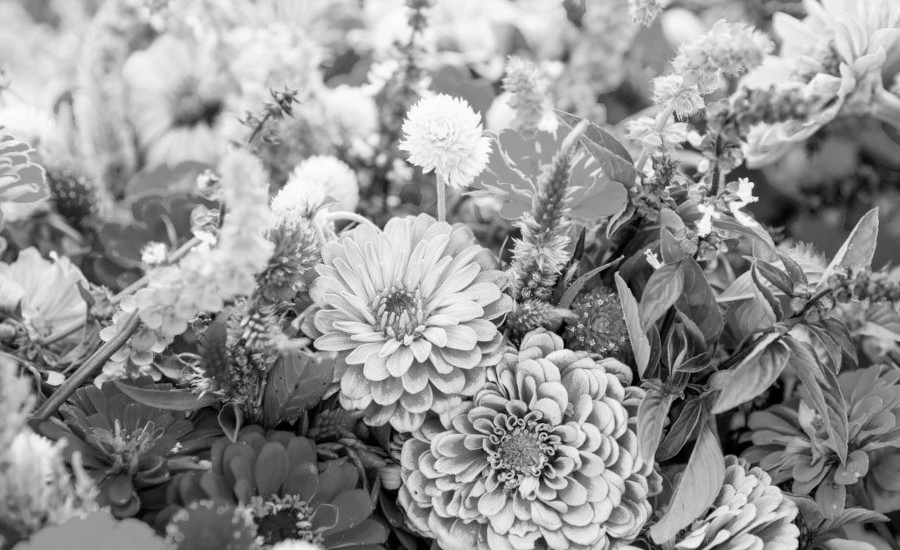

In [3]:
# TODO: open image and get pixels
img = PImage.open("./data/flowers.jpg")

ipxs = get_pixels(img)
print(len(ipxs), ipxs[0])

# TODO: make grayscale
gpxs = []
for r,g,b in ipxs:
  l = (r+g+b) // 3
  gpxs.append(l)

# OR: comprehension
gpxs = [(r+g+b) // 3 for r,g,b in ipxs]

# check lengths
print(len(gpxs), gpxs[0])

# check result
gimg = make_image(gpxs, img.width)
gimg

In [ ]:
# TODO: compare L and R neighbors of all pixels

epxs = [0] # first pixel and last pixel are skipped

for idx in range(1, len(gpxs)-1):
  L = gpxs[idx - 1]
  C = gpxs[idx]
  R = gpxs[idx + 1]
  epxs.append(abs(L - R))

epxs.append(0) # first pixel and last pixel are skipped

len(epxs)

eimg = make_image(epxs, img.width)
eimg

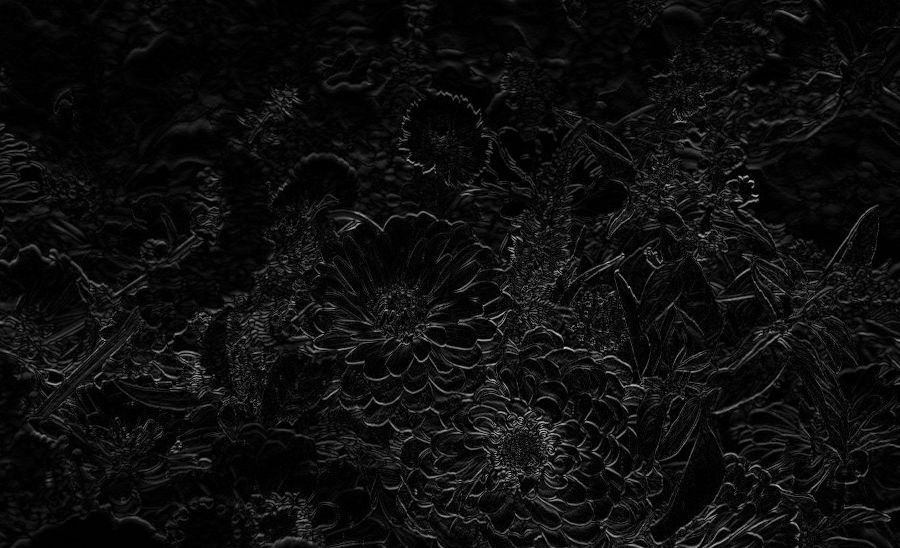

In [ ]:
# TODO: compare T and B neighbors of all pixels

# we'll skip first row and last row
hepxs = []

for idx in range(img.width, len(gpxs)-img.width):
  T = gpxs[idx - img.width]
  C = gpxs[idx]
  B = gpxs[idx + img.width]
  hepxs.append(abs(T - B))

# we skipped first row and last row
len(hepxs)

heimg = make_image(hepxs, img.width)
heimg